In [1]:
# Advanced Statistical Analysis - Temperature Trends
# CMPT 353 Final Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal
from pathlib import Path

plt.style.use("default")
np.random.seed(42)

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/tables").mkdir(parents=True, exist_ok=True)

print("Advanced Statistical Analysis::\n")

# getthe computed resukts form main notebook
trends_df = pd.read_csv("../outputs/tables/temperature_trends_results.csv")

print(trends_df.head(5).to_string(index=False))


Advanced Statistical Analysis::

city_name country_code  latitude  longitude  station_distance_km  years_analyzed  first_year  last_year  temp_trend_per_year  temp_trend_per_decade  ols_trend_per_decade  r_squared  t_statistic  p_value  significant_05  temp_2000_2009  temp_2015_2024  mean_temp_all_years  temp_std_dev
 Adjuntas           PR    18.163    -66.722                8.105               9        2000       2023             0.043905               0.439048              0.469334   0.473152     2.507302 0.040557            True        21.28975       22.256333            21.676667      0.548447
      Bor           RU    61.601     90.018                0.143               9        2000       2023             0.076591               0.765913              0.592635   0.138493     1.060799 0.324005           False        -2.15050       -1.189333            -1.781667      1.280053
 Burfjord           NO    69.938     22.052               13.298               9        2000       2023      

In [2]:
# testing data normality and climate zones

def test_data_normality(data, name):
    
    clean_data = data.dropna()
    shapiro_stat, shapiro_p = shapiro(clean_data)

    print(name + ":")
    print("Shapiro-Wilk: W =", round(shapiro_stat, 3), ", p =", round(shapiro_p, 3))

    if shapiro_p > 0.05:
        print("Data appears normally distributed")
        return True, shapiro_stat, shapiro_p
    else:
        print("Data is not normally distributed")
        return False, shapiro_stat, shapiro_p


temp_trends = trends_df["temp_trend_per_decade"].dropna()
is_normal, shapiro_stat, shapiro_p = test_data_normality(temp_trends, "Temperature Trends")


def assign_climate_zone(lat):
    abs_lat = abs(lat)
    if abs_lat >= 66.5:
        return "Polar"
    elif abs_lat >= 45:
        return "Temperate"
    elif abs_lat >= 23.5:
        return "Subtropical"
    else:
        return "Tropical"

trends_df["climate_zone"] = trends_df["latitude"].apply(assign_climate_zone)

ZONE_ORDER = ["Tropical", "Subtropical", "Temperate", "Polar"]


zone_groups = {}
for zone in ZONE_ORDER:
    zone_data = trends_df[trends_df["climate_zone"] == zone]["temp_trend_per_decade"].dropna()
    if len(zone_data) >= 2: 
        zone_groups[zone] = zone_data


print("\nClimate Zone Summary (in order):")
for zone, values in zone_groups.items():
    print(" ", zone + ":", len(values), "cities, mean =", round(values.mean(), 3), "degC/decade")






print("\nTesting assumptions for climate zone analysis: ")


levene_stat, levene_p = levene(*zone_groups.values())
print("Levene's test: F =", round(levene_stat, 3), ", p =", round(levene_p, 3))

equal_variances = levene_p > 0.05

if is_normal and equal_variances:
    # useing anova
    f_stat, anova_p = f_oneway(*zone_groups.values())
    test_used = "One-way ANOVA"
    print("Using parametric test:", test_used)
    print(test_used + ": F =", round(f_stat, 3), ", p =", round(anova_p, 3))
    zone_test_stat, zone_test_p = f_stat, anova_p
else:
    #  kruskal wallis
    h_stat, kw_p = kruskal(*zone_groups.values())
    test_used = "Kruskal-Wallis"
    print("\nUsing non-parametric test:", test_used)
    print(test_used + ": H =", round(h_stat, 3), ", p =", round(kw_p, 3))
    zone_test_stat, zone_test_p = h_stat, kw_p

if zone_test_p < 0.05:
    print("....Significant differences between climate zones.....")
else:
    print("....No significant differences between climate zones...")


Temperature Trends:
Shapiro-Wilk: W = 0.943 , p = 0.192
Data appears normally distributed

Climate Zone Summary (in order):
  Tropical: 6 cities, mean = 0.206 degC/decade
  Subtropical: 8 cities, mean = 0.328 degC/decade
  Temperate: 6 cities, mean = 0.404 degC/decade
  Polar: 4 cities, mean = 0.528 degC/decade

Testing assumptions for climate zone analysis: 
Levene's test: F = 0.566 , p = 0.644
Using parametric test: One-way ANOVA
One-way ANOVA: F = 0.581 , p = 0.634
....No significant differences between climate zones...


/var/folders/2d/bv2drtb15t5d17sk_fmphyxr0000gn/T/ipykernel_80679/2861138190.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(zone_data, labels=zone_labels, patch_artist=True)


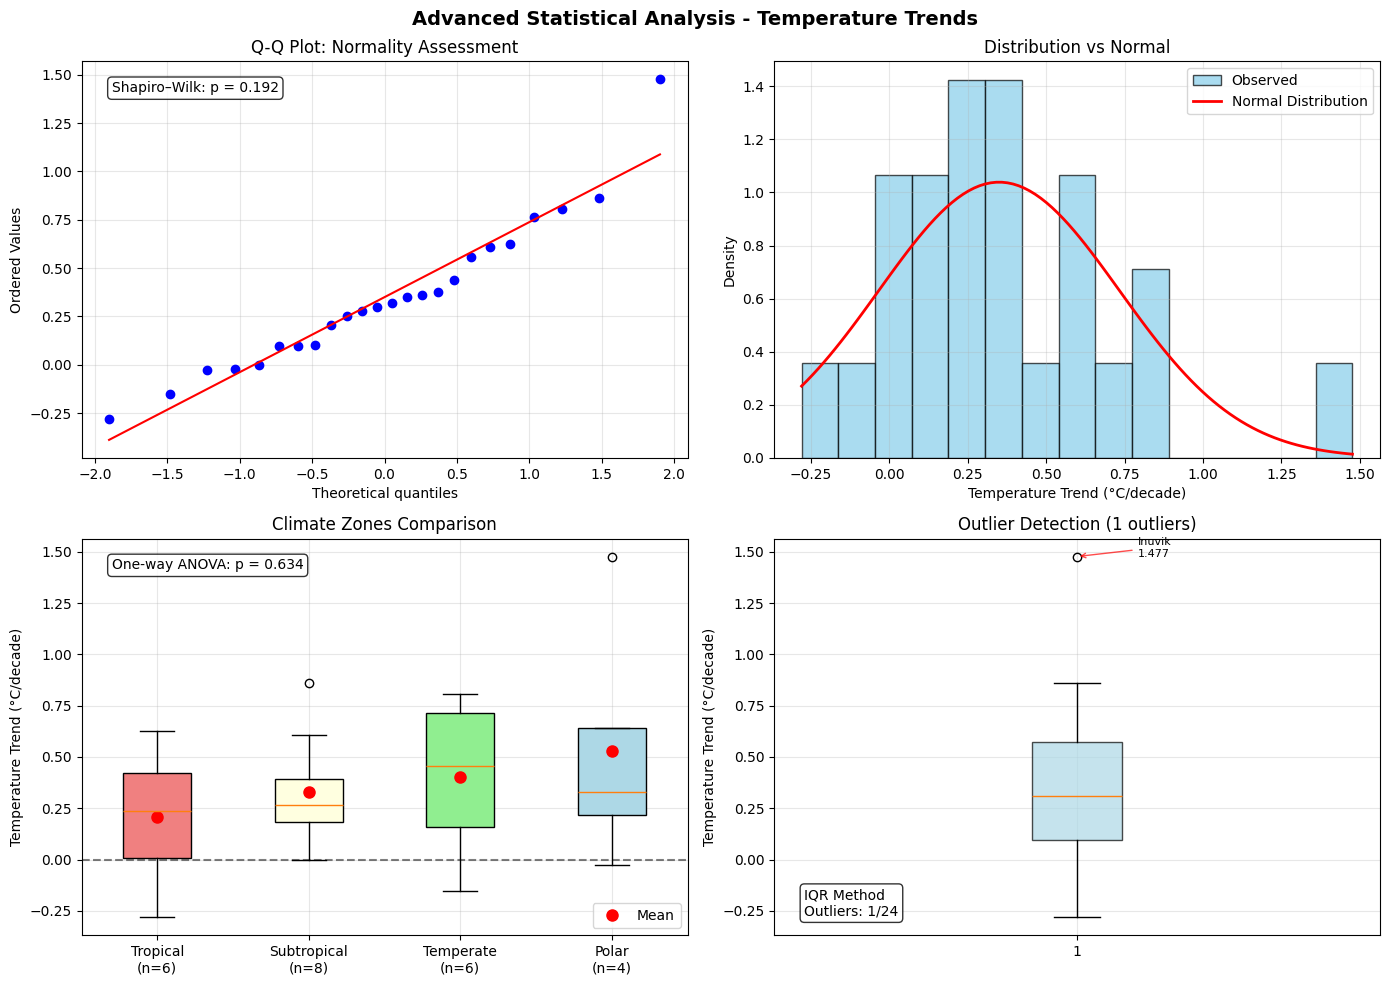

In [3]:

def create_advanced_stats_figure(trends_df, zone_groups, temp_trends, 
                                shapiro_stat, shapiro_p, zone_test_stat, 
                                zone_test_p, test_used):


    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Advanced Statistical Analysis - Temperature Trends",
                 fontsize=14, fontweight="bold")


    ax1 = axes[0, 0]
    stats.probplot(temp_trends, dist="norm", plot=ax1)
    ax1.set_title("Q-Q Plot: Normality Assessment")
    ax1.grid(True, alpha=0.3)
    ax1.text(
        0.05, 0.95, "Shapiro–Wilk: p = " + str(round(shapiro_p, 3)),
        transform=ax1.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        fontsize=10, va="top"
    )


    ax2 = axes[0, 1]
    ax2.hist(temp_trends, bins=15, density=True, alpha=0.7,
             color="skyblue", edgecolor="black", label="Observed")
    mu, sigma = temp_trends.mean(), temp_trends.std()
    x = np.linspace(temp_trends.min(), temp_trends.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    ax2.plot(x, normal_dist, "r-", linewidth=2, label="Normal Distribution")
    ax2.set_xlabel("Temperature Trend (°C/decade)")
    ax2.set_ylabel("Density")
    ax2.set_title("Distribution vs Normal")
    ax2.legend()
    ax2.grid(True, alpha=0.3)


    ax3 = axes[1, 0]
    if len(zone_groups) > 1:
        zone_data, zone_labels, zone_means = [], [], []
        for zone in ZONE_ORDER:
            if zone in zone_groups:
                values = pd.Series(zone_groups[zone]).dropna()
                if len(values) == 0:
                    continue
                zone_data.append(values.values)
                zone_labels.append(zone + "\n(n=" + str(len(values)) + ")")
                zone_means.append(values.mean())

        if zone_data:
            bp = ax3.boxplot(zone_data, labels=zone_labels, patch_artist=True)
            colors = ["lightcoral", "lightyellow", "lightgreen", "lightblue"]
            for patch, color in zip(bp["boxes"], colors[:len(bp["boxes"])]):
                patch.set_facecolor(color)
            # Add mean markers
            for i, m in enumerate(zone_means):
                ax3.plot(i + 1, m, "ro", markersize=8, label="Mean" if i == 0 else "")
            ax3.legend()

    ax3.axhline(y=0, color="black", linestyle="--", alpha=0.5)
    ax3.set_ylabel("Temperature Trend (°C/decade)")
    ax3.set_title("Climate Zones Comparison")
    ax3.grid(True, alpha=0.3)

    if not np.isnan(zone_test_p):
        ax3.text(
            0.05, 0.95, test_used + ": p = " + str(round(zone_test_p, 3)),
            transform=ax3.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            fontsize=10, va="top"
        )

    ax4 = axes[1, 1]
    bp = ax4.boxplot(trends_df["temp_trend_per_decade"].dropna(), patch_artist=True)
    bp["boxes"][0].set_facecolor("lightblue")
    bp["boxes"][0].set_alpha(0.7)


    Q1 = trends_df["temp_trend_per_decade"].quantile(0.25)
    Q3 = trends_df["temp_trend_per_decade"].quantile(0.75)
    IQR = Q3 - Q1
    outliers = trends_df[
        (trends_df["temp_trend_per_decade"] < Q1 - 1.5 * IQR) |
        (trends_df["temp_trend_per_decade"] > Q3 + 1.5 * IQR)
    ].copy()

    max_labels = 4 if len(trends_df) <= 50 else 2
    if len(outliers) > 0 and max_labels > 0:
        outliers_sorted = outliers.sort_values("temp_trend_per_decade")
        label_outliers = pd.concat([
            outliers_sorted.head(max_labels // 2),  # most cooling
            outliers_sorted.tail(max_labels // 2)   # most warming
        ]).drop_duplicates()
        for i, (_, row) in enumerate(label_outliers.iterrows()):
            x_pos = 1.1 + (i % 2) * 0.15  # spread labels
            ax4.annotate(
                row['city_name'][:8] + "\n" + str(round(row['temp_trend_per_decade'], 3)),
                xy=(1, row["temp_trend_per_decade"]),
                xytext=(x_pos, row["temp_trend_per_decade"]),
                fontsize=8, ha="left",
                arrowprops=dict(arrowstyle="->", color="red", alpha=0.7)
            )

    ax4.set_ylabel("Temperature Trend (°C/decade)")
    ax4.set_title("Outlier Detection (" + str(len(outliers)) + " outliers)")
    ax4.grid(True, alpha=0.3)
    ax4.text(
        0.05, 0.05, "IQR Method\nOutliers: " + str(len(outliers)) + "/" + str(len(trends_df)),
        transform=ax4.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        fontsize=10
    )

    plt.tight_layout()
    return fig, outliers


advanced_fig, outliers = create_advanced_stats_figure(
    trends_df, zone_groups, temp_trends, shapiro_stat, shapiro_p,
    zone_test_stat, zone_test_p, test_used
)
advanced_fig.savefig("../outputs/figures/advanced_stats.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:

print("\nStatistical Test Summary")

print("Test Results:")


print("Shapiro-Wilk Normality: W =", round(shapiro_stat, 3), ", p =", round(shapiro_p, 3))
if shapiro_p > 0.05:
    print("Som , Normal - Parametric tests justified")
else:
    print("So, Non-normal - Consider non-parametric\n")



# Climate zone test  
if not np.isnan(zone_test_p):
    print(test_used + ":", round(zone_test_stat, 3), ", p =", round(zone_test_p, 3))
    if zone_test_p < 0.05:
        print("Significant - Zone differences exist")
    else:
        print("Not significant - No zone differences detected\n")
    print()

print("Outlier Detection (IQR):", len(outliers), "outliers, p = N/A")
print(str(len(outliers)) + "/" + str(len(trends_df)), "cities - Outliers flagged but retained\n")



outlier_summary = outliers[[
    "city_name", "country_code", "latitude", 
    "temp_trend_per_decade", "r_squared"
]].copy()
outlier_summary.to_csv("../outputs/tables/outlier_cities.csv", index=False)
print("Outlier cities saved to ../outputs/tables/outlier_cities.csv")



print("\nOutlier cities:")
for _, outlier in outliers.iterrows():
    print(outlier['city_name'] + ":", round(outlier['temp_trend_per_decade'], 3), "degC/decade")


print("\nAdvanced statistical analysis complete")
print("Figure saved to ../outputs/figures/advanced_stats.png")



print("Checks:")
print("Cities analyzed:", len(trends_df))


print("Shapiro-Wilk p-value:", round(shapiro_p, 3))
print("Kruskal-Wallis p-value:", round(zone_test_p, 3))
print("Outliers found:", len(outliers))

print("All figures saved:")
print("../outputs/figures/advanced_stats.png")


Statistical Test Summary
Test Results:
Shapiro-Wilk Normality: W = 0.943 , p = 0.192
Som , Normal - Parametric tests justified
One-way ANOVA: 0.581 , p = 0.634
Not significant - No zone differences detected


Outlier Detection (IQR): 1 outliers, p = N/A
1/24 cities - Outliers flagged but retained

Outlier cities saved to ../outputs/tables/outlier_cities.csv

Outlier cities:
Inuvik: 1.477 degC/decade

Advanced statistical analysis complete
Figure saved to ../outputs/figures/advanced_stats.png
Checks:
Cities analyzed: 24
Shapiro-Wilk p-value: 0.192
Kruskal-Wallis p-value: 0.634
Outliers found: 1
All figures saved:
../outputs/figures/advanced_stats.png
